## Load Stuff

In [1]:
import torch
from mario_gpt import MarioDataset, MarioLM, TrainingConfig, MarioGPTTrainer
from mario_gpt.utils import view_level, convert_level_to_png, join_list_of_list, characterize

In [2]:
BASE = "distilgpt2"

In [3]:
from transformers import AutoConfig, AutoModelWithLMHead

In [4]:
mario_lm = MarioLM()

Using shyamsn97/Mario-GPT2-700-context-length lm


/opt/conda/lib/python3.10/site-packages/transformers-4.46.3-py3.10.egg/transformers/models/auto/modeling_auto.py:1833: FutureWarning: The class `AutoModelWithLMHead` is deprecated and will be removed in a future version. Please use `AutoModelForCausalLM` for causal language models, `AutoModelForMaskedLM` for masked language models and `AutoModelForSeq2SeqLM` for encoder-decoder models.
  warnings.warn(


Using shyamsn97/Mario-GPT2-700-context-length tokenizer


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


### Load Dataset (Optional)

In [5]:
dataset = MarioDataset(tokenizer=mario_lm.tokenizer, folder_path='/mario-gpt/txt')

Token indices sequence length is longer than the specified maximum sequence length for this model (3360 > 1024). Running this sequence through the model will result in indexing errors


In [6]:
view_level(dataset.data[1]["input_ids"][:700], mario_lm.tokenizer)

['--------------------------------------------------',
 '--------------------------------------------------',
 '--------------------------------------------------',
 '--------------------------------------------------',
 '--------------------------------------------------',
 '----------------------------------------C---------',
 '--------------------------------C-----------------',
 '-----------------------------oo-----------------oo',
 '----------------------------o------------------o--',
 '------------!---?!------oo-------------SCS--------',
 '-----------------------o-----XXXXXX---------------',
 '-----------------------------XXXXXX---------------',
 '------------------g-----XXXXXXXXXXX------------XXX',
 'XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX']

/opt/conda/lib/python3.10/site-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


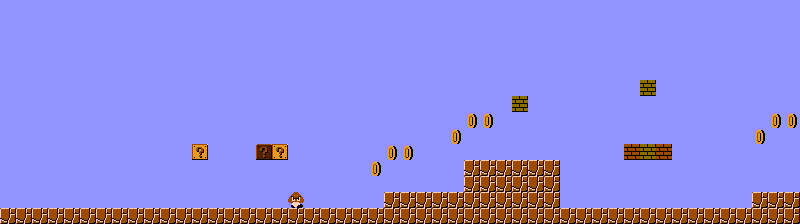

In [7]:
img = convert_level_to_png(dataset.data[1]["input_ids"][:700],  mario_lm.tokenizer)[0]
img

### Setup training

In [14]:
config = TrainingConfig(save_iteration=10)

In [15]:
trainer = MarioGPTTrainer(mario_lm, dataset, config=config)

/opt/conda/lib/python3.10/site-packages/transformers-4.46.3-py3.10.egg/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [16]:
trainer.train(100, batch_size=1)

Training for 100 Iterations and batch_size 1
================== Training Config ==================
gradient_accumulation_steps -- 1
mixed_precision -- no
output_dir -- Mario-GPT2-700-context-length
learning_rate -- 0.0005
epsilon -- 1e-09
lr_warmup_steps -- 1000
batch_size -- 4
total_steps -- 50000
mask_proportion -- 0.0
eval_iteration -- 1000
save_iteration -- 10
================== MarioLM ==================
Follow tensorboard with: python -m tensorboard.main --logdir /mario-gpt/Mario-GPT2-700-context-length


{'loss': 1.1560299396514893, 'last_lr': 5e-05}: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.90it/s]
